In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# from Q_Seg_main.qseg.dwave_utils import *
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [16]:
# load new images
path = "datasets/spheroidite_particles/"
image_files = [f for f in os.listdir(path+"image_patches/")]
mask_files = [f for f in os.listdir(path+"label_patches/")]

images = [cv2.imread(path+"image_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in image_files]
masks = [cv2.imread(path+"label_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in mask_files]

In [37]:
def optimize_pipeline(raw_image, mask):
    # Match sequential step 1: Sharpen image first
    image = sharpnening(raw_image)
    dim = image.shape[0]

    # Construct base graph once from sharpened image
    start = time.time()
    G_base, dmin, dmax = construct_graph(image)
    end = time.time()
    conversion_time = round(end-start,3)
    
    thresholds = [0, 0.1, 0.2]
    k_values = [0, 0.1, 0.2]  
    
    results = []
    
    for th, k in product(thresholds, k_values):
        G = copy.deepcopy(G_base)
        
        start_time = time.time() #
        H, I, important, redundant = importance_sampling(
            G, threshold=th, node_size=0.1, show_graph=False)
        if k > 0:
            sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=k, seed=0)
            I.add_nodes_from(sampled_nodes)
        I = update_edgeweights(I, image, dim, dmin, dmax, close_loop='rc', mode=1)
        end = time.time()
        sampling_time = round(end-start,3)

        # solve QUBO
        start = time.time()
        bqm, sampleset = annealer_solver_sa(I)
        sampleset_first = sampleset.first.sample
        end = time.time()
        annealing_time = round(end-start,3)
        
        start_time = time.time() ##
        # label propagation
        metrics_df = label_propagation_graph(I, sampleset_first, dim, mask)
        labeling_time = time.time() - start_time ##
        
        results.append({
            'thresholds':th,
            'k_values':k,
            'Accuracy': metrics_df['accuracy'].iloc[0],
            'IoU': metrics_df['iou'].iloc[0],
            'Precision': metrics_df['precision'].iloc[0],
            'Recall': metrics_df['recall'].iloc[0],
            'F1': metrics_df['f1'].iloc[0],
            'Conversion time': conversion_time,
            'Sampling time' : sampling_time,
            'Annealing time' : annealing_time,
            'Labeling time' : labeling_time

        })
        
    df_results = pd.DataFrame(results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

    return best_config

In [38]:
df = pd.DataFrame(columns=['idx', 'thresholds', 'k', 'Accuracy', 'IoU', 'Precision', 'Recall', 'F1', 'Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'])

In [39]:
for i in range(len(images)):
    best_config = optimize_pipeline(images[i], masks[i])
    df.loc[len(df)] = [i] + best_config.round(3).tolist()
    
df

,idx,thresholds,k,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
0,0.0,0.1,0.2,0.958,0.795,0.900,0.856,0.877,0.610,9.073,5.881,2.900
1,1.0,0.1,0.2,0.951,0.790,0.884,0.865,0.874,0.620,11.097,7.636,2.593
2,2.0,0.1,0.1,0.934,0.766,0.895,0.830,0.858,0.647,10.609,7.295,2.838
3,3.0,0.1,0.2,0.932,0.751,0.886,0.816,0.846,0.593,11.055,7.910,3.309
4,4.0,0.2,0.2,0.946,0.792,0.914,0.847,0.876,0.840,11.393,8.196,2.799
5,5.0,0.1,0.2,0.960,0.823,0.928,0.871,0.897,0.599,9.364,6.430,2.716
6,6.0,0.1,0.1,0.949,0.770,0.891,0.832,0.859,0.619,8.187,4.558,2.737
7,7.0,0.2,0.2,0.953,0.776,0.911,0.828,0.863,0.590,9.990,6.417,2.360
8,8.0,0.1,0.2,0.932,0.777,0.884,0.852,0.867,0.861,12.167,8.328,2.415
9,9.0,0.0,0.1,0.931,0.776,0.879,0.856,0.867,0.656,10.127,6.215,2.609


In [43]:
df.to_csv('spherodite_this_work.csv', index=False)

In [44]:
df.describe().loc[['mean', '50%']].round(3)

,idx,thresholds,k,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
mean,9.5,0.065,0.155,0.942,0.778,0.889,0.847,0.866,0.729,10.112,6.625,2.781
50%,9.5,0.100,0.200,0.942,0.776,0.887,0.846,0.865,0.642,10.023,6.424,2.768


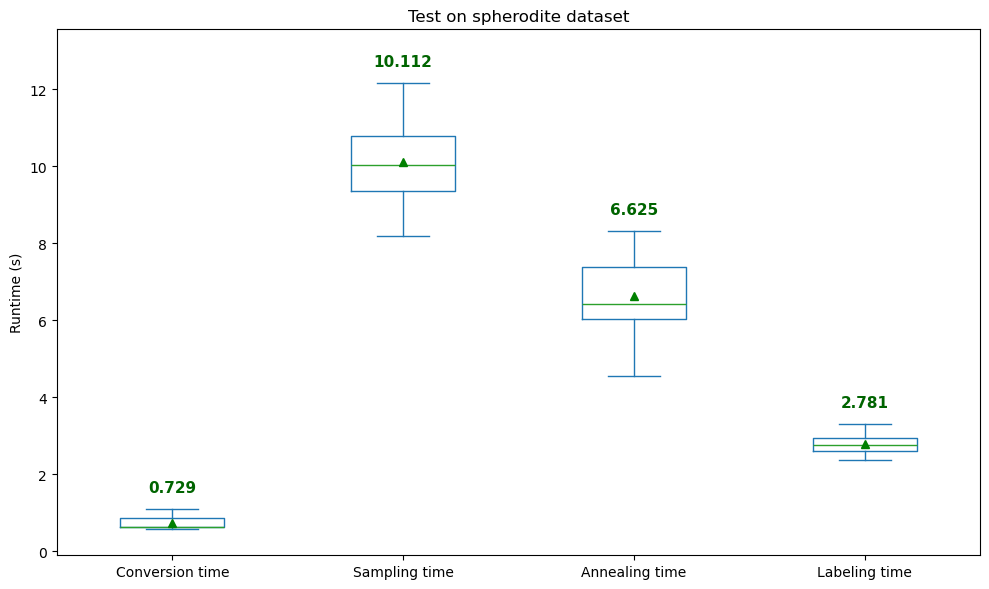

In [46]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')
df_runtime = df_runtime[['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

In [47]:
df.drop(columns=['idx', 'thresholds', 'k', 'Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'], inplace=True)

QUBO w/o sampling

In [22]:
results_qubo = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    G, dmin, dmax = construct_graph(sample)
    end = time.time()
    conversion_time = round(end-start,3)

    start = time.time()
    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)
    
    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results_qubo.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Conversion time': conversion_time,
        'Annealing time' : annealing_time,
    })

df_qubo = pd.DataFrame(results_qubo)
df_qubo

,Accuracy,IoU,Precision,Recall,F1,Conversion time,Annealing time
0,0.505,0.178,0.638,0.520,0.232,0.574,32.652
1,0.487,0.173,0.634,0.517,0.228,0.557,32.908
2,0.443,0.159,0.615,0.507,0.215,0.541,32.985
3,0.434,0.156,0.620,0.502,0.212,0.597,34.136
4,0.501,0.179,0.626,0.527,0.233,0.573,31.781
5,0.458,0.163,0.630,0.506,0.219,0.913,32.032
6,0.523,0.185,0.637,0.529,0.238,0.580,32.183
7,0.488,0.172,0.633,0.515,0.227,0.577,33.115
8,0.446,0.161,0.614,0.510,0.217,0.987,32.944
9,0.478,0.172,0.615,0.523,0.226,0.575,33.497


In [23]:
df_qubo.to_csv('spherodite_qubo.csv', index=False)

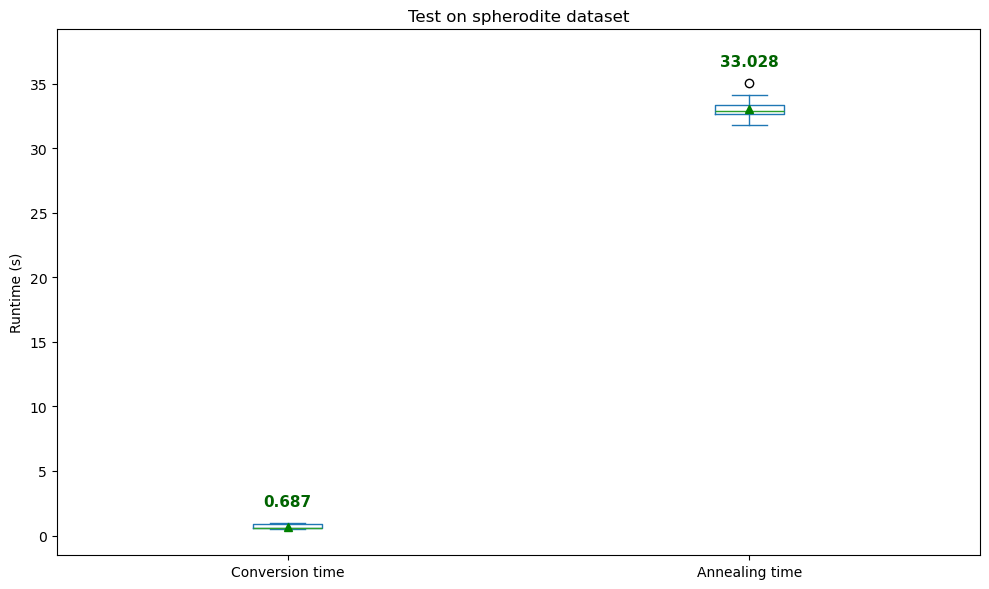

In [25]:
if 'idx' in df_qubo.columns:
    df_qubo = df_qubo.set_index('idx')

df_runtime = df_qubo[['Conversion time', 'Annealing time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

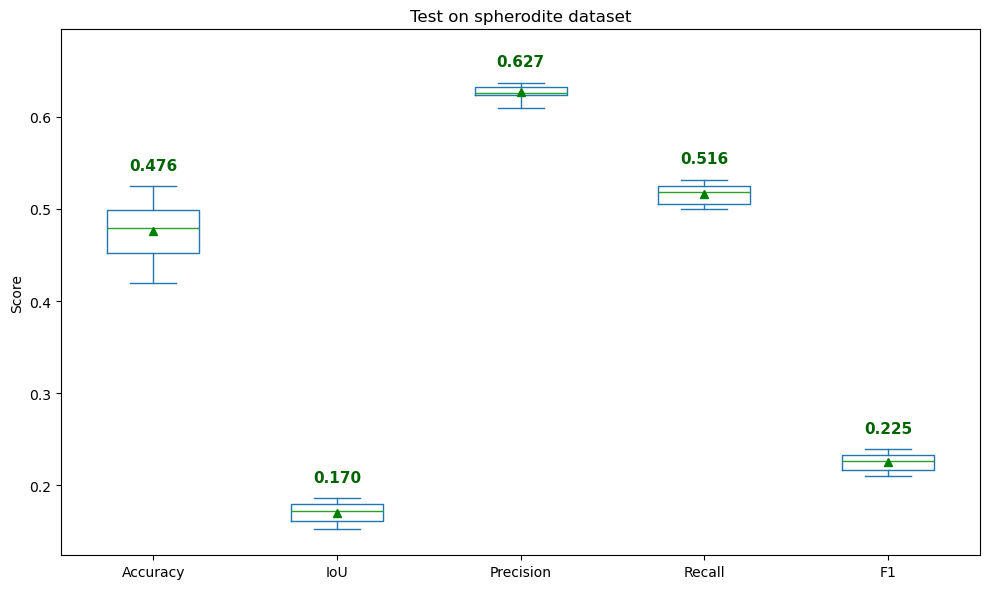

In [ ]:
# df_qubo.drop(columns=['Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_qubo.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_qubo.values.max() - df_qubo.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_qubo.columns, start=1):
    mean_val = df_qubo[col].mean()
    max_val = df_qubo[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_qubo.values.min() - y_offset * 2, df_qubo.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()